____
# BIOSWOT : Sensitivity to stain and vorticity


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_variance_groupby,
    compute_variance,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Characteritics :
- from April 20th to 18th (cycle 497-515)
- 4-5°E; 40.3-41.3°N
- move from W to E
- size ?

In [2]:
def sel_bioswot(dfr):
    id = dfr[
        (dfr.longitude > 4.75)
        & (dfr.longitude < 5.5)
        & (dfr.latitude > 40.3)
        & (dfr.latitude < 41.3)
        & (dfr.cycle_number > 498)
        & (dfr.cycle_number < 523)
    ].drifter_id.unique()

    dfr = dfr[
        (
            (dfr.drifter_id.isin(id))
            & (dfr.longitude > 4)
            & (dfr.longitude < 5.5)
            & (dfr.latitude > 40.3)
            & (dfr.latitude < 41.3)
            & (dfr.cycle_number > 498)
            & (dfr.cycle_number < 523)
            & (~((dfr.longitude < 4.75) & (dfr.latitude < 40.6)))
        )
    ]
    return dfr


def generate_0_15m_coloc_dataframe(freq_band):

    DT = 12

    # SURFACE
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="0",
    )

    comb_list = [base_dic]

    ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    ds0 = ds0.where(ds0.depth == 0, drop=True)
    # distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
    # ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
    # ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
    # ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
    # ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

    df0 = ds0.to_dataframe().reset_index().set_index("row_number")

    # DEPTH 15M
    base_dic = dict(
        dt="12h",
        drifter_preprocess="spectral_decomp",
        drifter_preprocess_param=freq_band,
        alti_product_key="swot2km",
        alti_diff_method="fromduacsv",
        alti_diff_method_param="",
        ggd_var="fromduacsv",
        wd_product_key="era5",
        wd_model="rio",
        wd_depth="15",
    )

    comb_list = [
        base_dic,
    ]

    ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
    ds15 = ds15.where(ds15.depth == 15, drop=True)
    # distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
    # ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
    ds15 = ds15.where(ds15.time_to_swot / pd.Timedelta("1h") < DT, drop=True)
    # ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
    # ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

    df15 = ds15.to_dataframe().reset_index().set_index("row_number")

    return df0, df15

In [3]:
bbox = [4, 5.5, 40.3, 41.3]

product = "swot2km"
dss3 = xr.open_dataset(
    os.path.join(
        zarr_dir,
        "before_coloc",
        "preprocessed_swot",
        product,
        "general",
        f"pass3_{product}_general.nc",
    )
)
dss3 = xr.merge(
    [
        dss3,
        xr.open_dataset(
            os.path.join(
                zarr_dir,
                "before_coloc",
                "preprocessed_swot",
                product,
                "diff_only",
                f"pass3_{product}_diff_only.nc",
            )
        ),
    ],
    compat="override",
)
dss3 = dss3.where(dss3.distance_to_coast > 20e3, drop=True)
dss3 = dss3.sel(cycle_number=slice(499, 522))
dss3 = dss3.where(
    (dss3.longitude > 4)
    & (dss3.longitude < 5.5)
    & (dss3.latitude > 40.3)
    & (dss3.latitude < 41.3),
    drop=True,
)
dss3["time"] = dss3.time - np.timedelta64(946684800000000000, "ns")

dfr = prepared_drifters(
    "12h", drifter_preprocess="spectral_decomp", drifter_preprocess_param="inertial"
)
dfr = sel_bioswot(dfr)

depthcolor = {0: "navy", 15: "green", 50: "yellowgreen", 100: "yellow"}
dfr["depthcolor"] = [depthcolor[d] for d in dfr.depth]


era = xr.open_dataset(
    os.path.join(zarr_dir, "before_coloc", "wind", "era5_agesc_rio_z0.nc")
)

NameError: name 'dfr' is not defined

# Time evolution of the different components along trajectories

In [5]:
DF15 = dict()
DF0 = dict()

for spectral_band in ["", "LF", "inertial", "diurnal", "semidiurnal"]:
    df0, df15 = generate_0_15m_coloc_dataframe(spectral_band)
    dfs = prepared_alti(
        dt="12h",
        drifter_preprocess="",
        drifter_preprocess_param="",
        alti_product_key="swot2km",
        alti_diff_method="xarray_diff",
        alti_diff_method_param="",
    )

    def concat(df, dfs):
        df = pd.concat(
            [
                df,
                dfs[
                    [
                        "vorticity_etaf",
                        "strain_s_etaf",
                        "strain_n_etaf",
                    ]
                ],
            ],
            axis=1,
        ).dropna()
        df["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(df.latitude * np.pi / 180)
        fo = df.f.mean()
        df["strain_f"] = np.sqrt(df.strain_n_etaf**2 + df.strain_s_etaf**2)
        df["strain"] = (
            df.strain_f * df.f
        )  # .assign_attrs({'long_name':r'$\sigma/|f|$'})
        df["vorticity"] = (
            df.vorticity_etaf * df.f
        )  # .assign_attrs({'long_name':r'$\zeta/f$'})
        df[
            "vorticity_f"
        ] = df.vorticity_etaf  # .assign_attrs({'long_name':r'$\zeta/f$'})
        df["omega"] = df.strain**2 - df.vorticity**2
        return df

    DF0[spectral_band] = sel_bioswot(concat(df0, dfs))
    DF15[spectral_band] = sel_bioswot(concat(df15, dfs))

Index(['pass_number', 'datetime', 'drifter_id', 'u10', 'v10', 't2m', 'ewss',
       'iews', 'inss', 'msl',
       ...
       'gap_mask', 'inside_left', 'inside_right', 'longitude', 'latitude',
       'time', 'drifter_type', 'time_to_swot', 'cycle_number', 'cycle_date'],
      dtype='object', length=129) vsde
Index(['vsde_agesc_z15', 'vsdn_agesc_z15', 'vsde_rio_z15', 'vsdn_rio_z15',
       'vsde_rioold_z15', 'vsdn_rioold_z15', 'vsde_agesc_z0', 'vsdn_agesc_z0',
       'vsde_rio_z0', 'vsdn_rio_z0', 'vsde_rioold_z0', 'vsdn_rioold_z0',
       'HFvsde_rio_z0', 'HFvsdn_rio_z0', 'HFvsde_rio_z15', 'HFvsdn_rio_z15',
       'LFvsde_rio_z0', 'LFvsdn_rio_z0', 'LFvsde_rio_z15', 'LFvsdn_rio_z15',
       'inertialvsde_rio_z0', 'inertialvsdn_rio_z0', 'inertialvsde_rio_z15',
       'inertialvsdn_rio_z15', 'diurnalvsde_rio_z0', 'diurnalvsdn_rio_z0',
       'diurnalvsde_rio_z15', 'diurnalvsdn_rio_z15', 'semidiurnalvsde_rio_z0',
       'semidiurnalvsdn_rio_z0', 'semidiurnalvsde_rio_z15',
       'semidiurna

In [8]:
DF0["All"] = DF0[""]
DF15["All"] = DF15[""]

In [ ]:
DF0["All"].columns

300534061398910


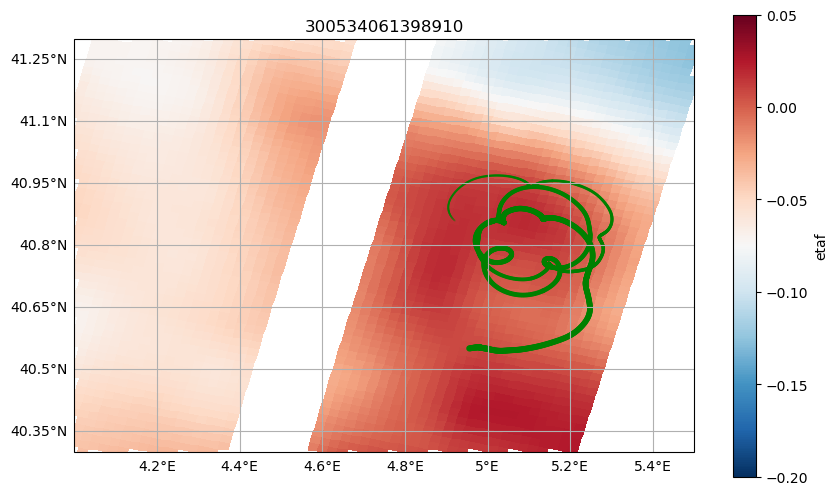

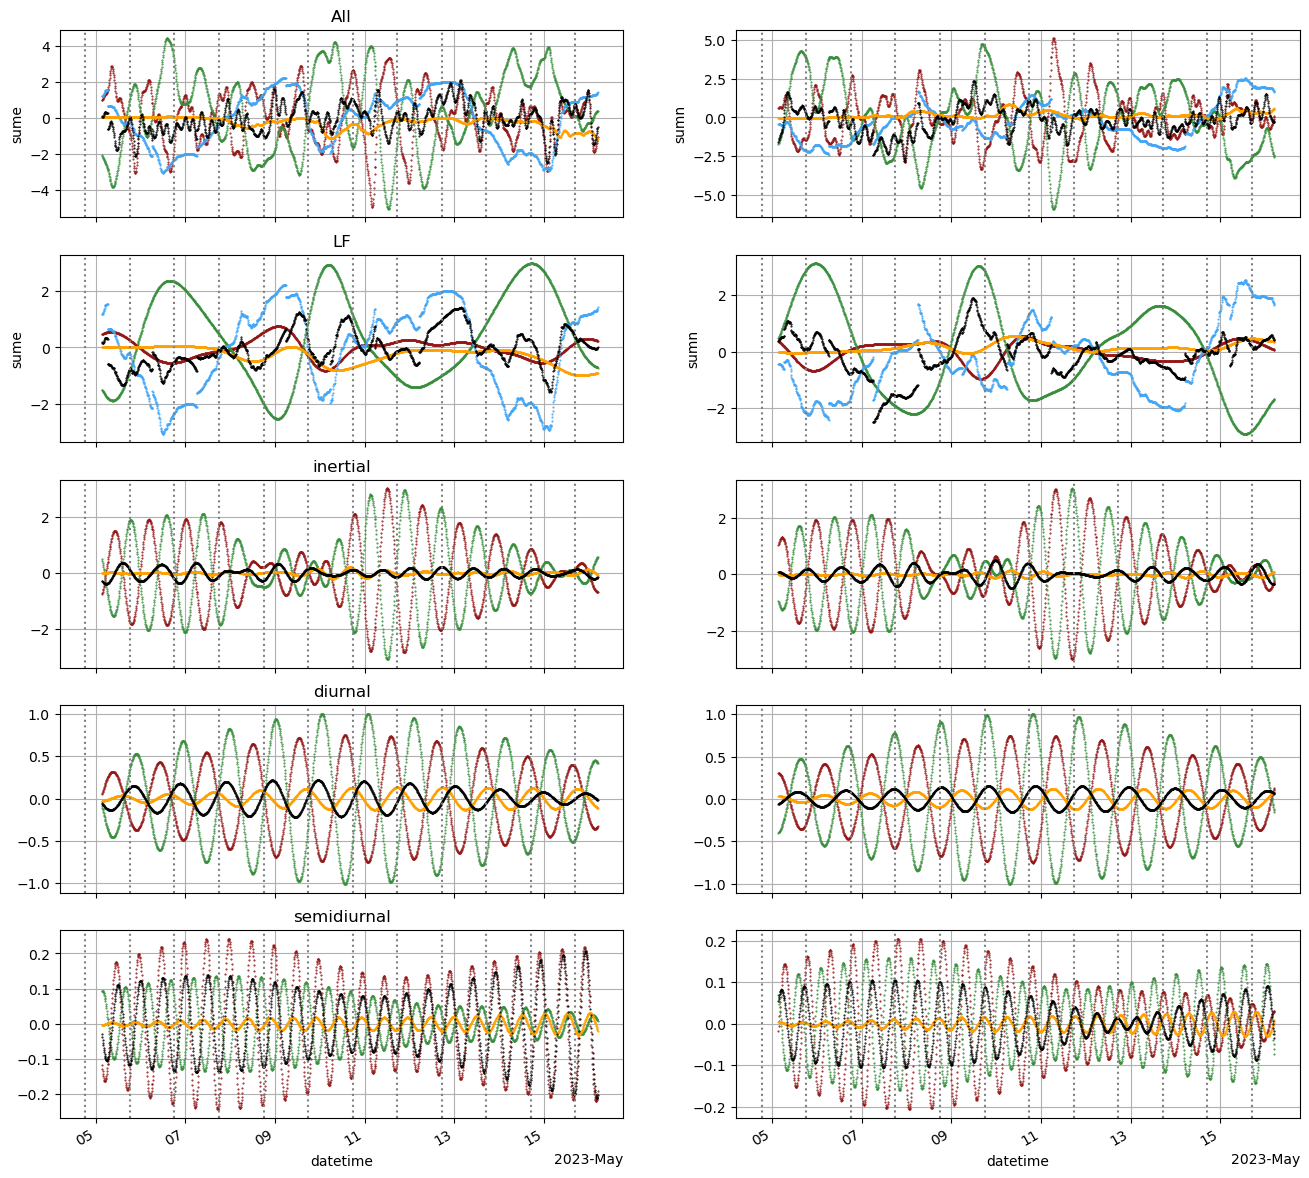

In [9]:
from matplotlib.gridspec import GridSpec
from cstes import U


def plot_timeseries_all(DF, i):
    df = DF["All"]

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(10, 6),
        frameon=False,
        subplot_kw=dict(projection=ccrs.PlateCarree()),
    )
    did = df.drifter_id.unique()
    kw = dict(transform=crs, cmap="RdBu_r", vmin=-0.2, vmax=0.05)
    dss3.sel(cycle_number=512).etaf.plot(x="longitude", y="latitude", ax=ax, **kw)
    print(did[i])
    df_ = df[df.drifter_id == did[i]]
    df_.set_index("datetime").plot.scatter(
        x="longitude",
        y="latitude",
        s=(df_.datetime - df_.datetime.min()) / pd.Timedelta("1d"),
        ax=ax,
        transform=crs,
        color=depthcolor[df_.depth.mean()],
    )
    ax.set_title(did[i])
    ax.set_extent(bbox)
    gl = ax.gridlines(
        draw_labels=True,
    )
    gl.top_labels = False
    gl.right_labels = False

    fig, axs = plt.subplots(5, 2, figsize=(16, 16), frameon=False, sharex=True)
    axs = axs.flatten()
    j = 0
    for spectral_band in ["All", "LF"]:
        # Time series
        df = DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ = df_.set_index("datetime")

        ax = axs[j]
        for v in ["acc", "cor", "ggd", "wd"]:
            (df_[v + "e"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        (df_["sum" + "e"] / U).to_xarray().plot(
            ax=ax, color="k", marker=".", ls="", markersize=1
        )
        for t in (
            dss3.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        ax.set_title(spectral_band)

        ax = axs[j + 1]
        for v in ["acc", "cor", "ggd", "wd"]:
            (df_[v + "n"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        (df_["sum" + "n"] / U).to_xarray().plot(
            ax=ax, color="k", marker=".", ls="", markersize=1
        )
        for t in (
            dss3.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        j += 2

    for spectral_band in ["inertial", "diurnal", "semidiurnal"]:
        # Time series
        df = DF[spectral_band]
        df_ = df[df.drifter_id == did[i]]
        df_ = df_.set_index("datetime")

        ax = axs[j]
        for v in ["acc", "cor", "wd"]:
            (df_[v + "e"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        # (df_['sum'+'e']/U).to_xarray().plot(ax=ax, color=c0['sum'], marker='.',ls='', markersize=1)
        ((df_["acce"] + df_["core"] + df_["wde"]) / U).dropna().plot(
            ax=ax, color="k", ls="", marker=".", markersize=1
        )
        for t in (
            dss3.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        ax.set_title(spectral_band)

        ax = axs[j + 1]
        for v in ["acc", "cor", "wd"]:
            (df_[v + "n"] / U).dropna().plot(
                ax=ax, color=c0[v], ls="", marker=".", markersize=1
            )
        ((df_["accn"] + df_["corn"] + df_["wdn"]) / U).dropna().plot(
            ax=ax, color="k", ls="", marker=".", markersize=1
        )
        for t in (
            dss3.time.sel(
                cycle_number=slice(df_.cycle_number.min(), df_.cycle_number.max())
            )
            .mean("num_lines")
            .values
        ):
            ax.axvline(t, ls=":", color="grey")
        ax.grid()
        j += 2

    # fig.tight_layout()
    # fig.savefig(os.path.join(zarr_dir, 'diag_files', 'synth_timeseries_images', did[i]+'.pdf'))
    # plt.close()


plot_timeseries_all(DF15, 15)

147


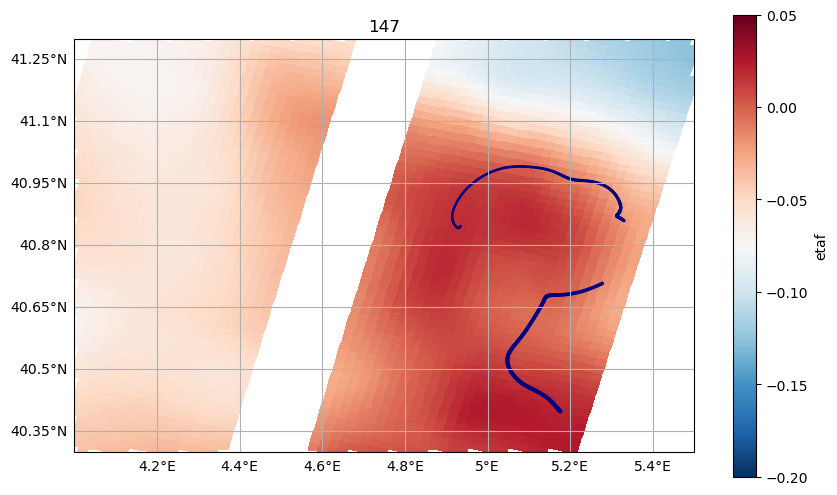

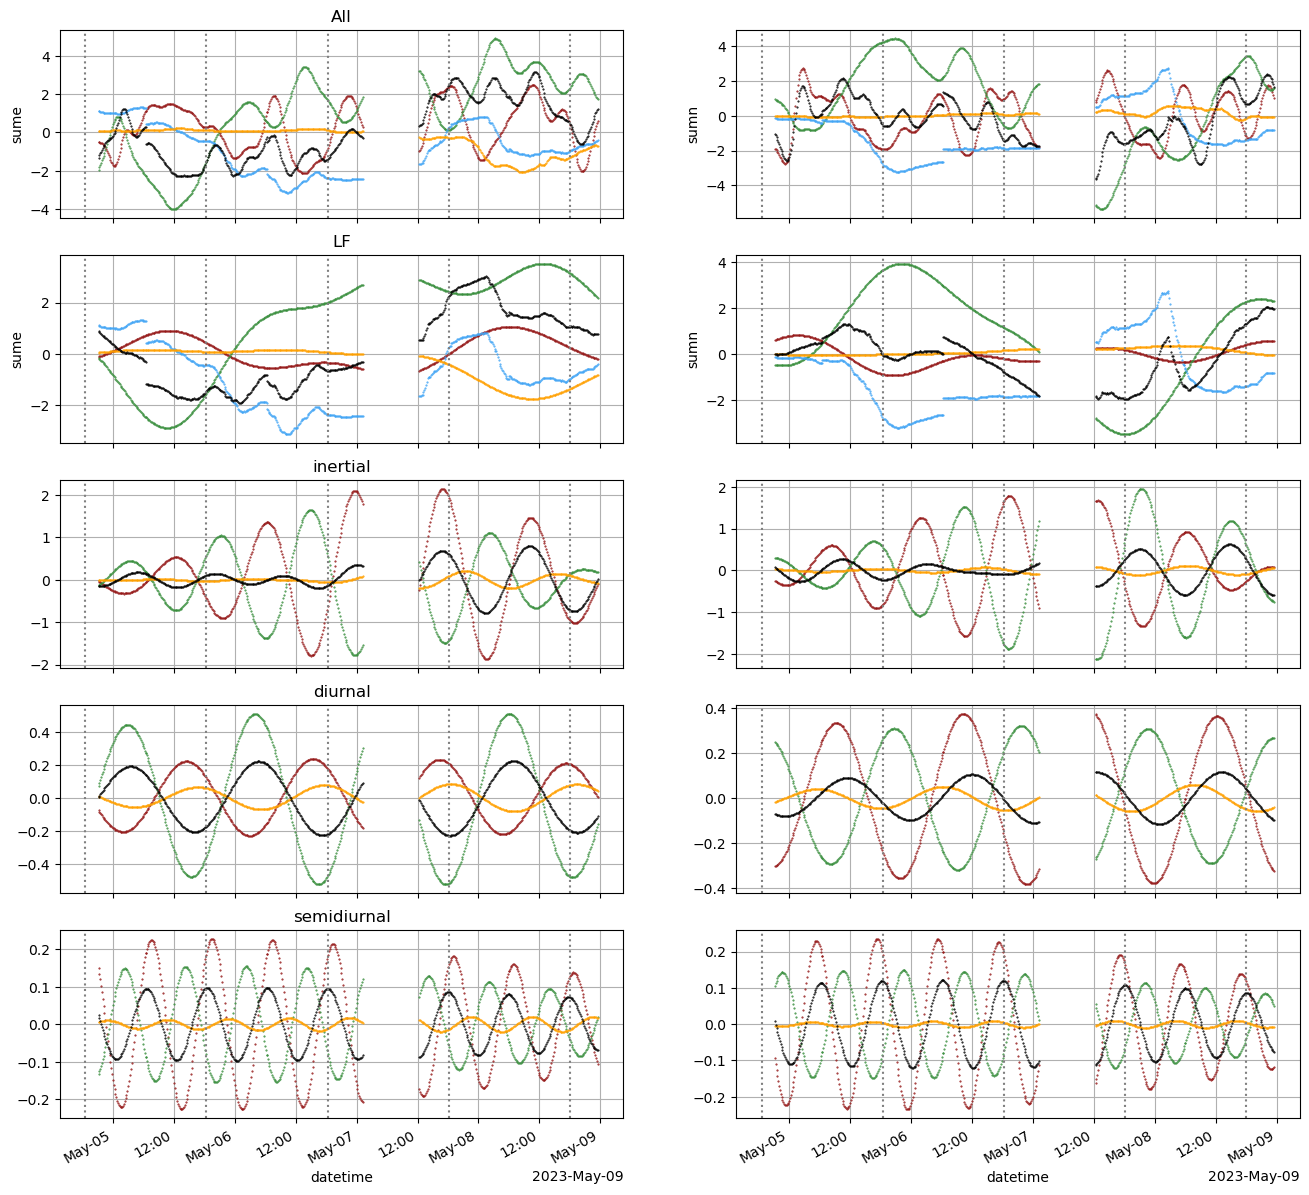

In [11]:
plot_timeseries_all(DF0, 26)

7


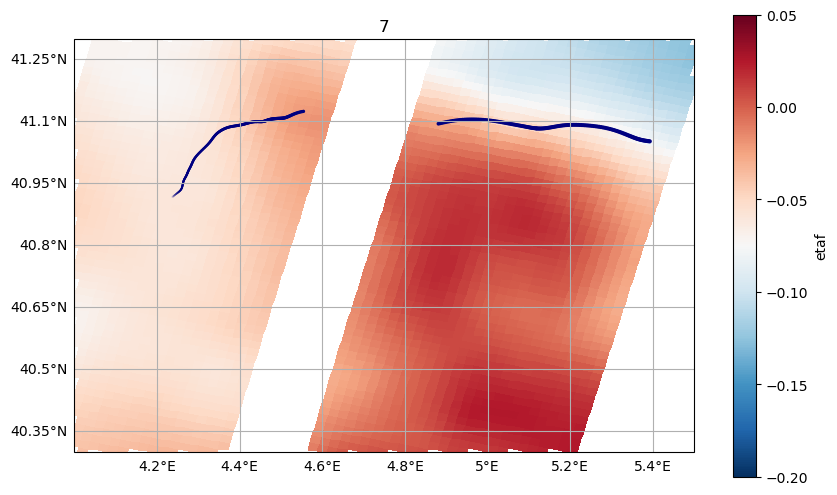

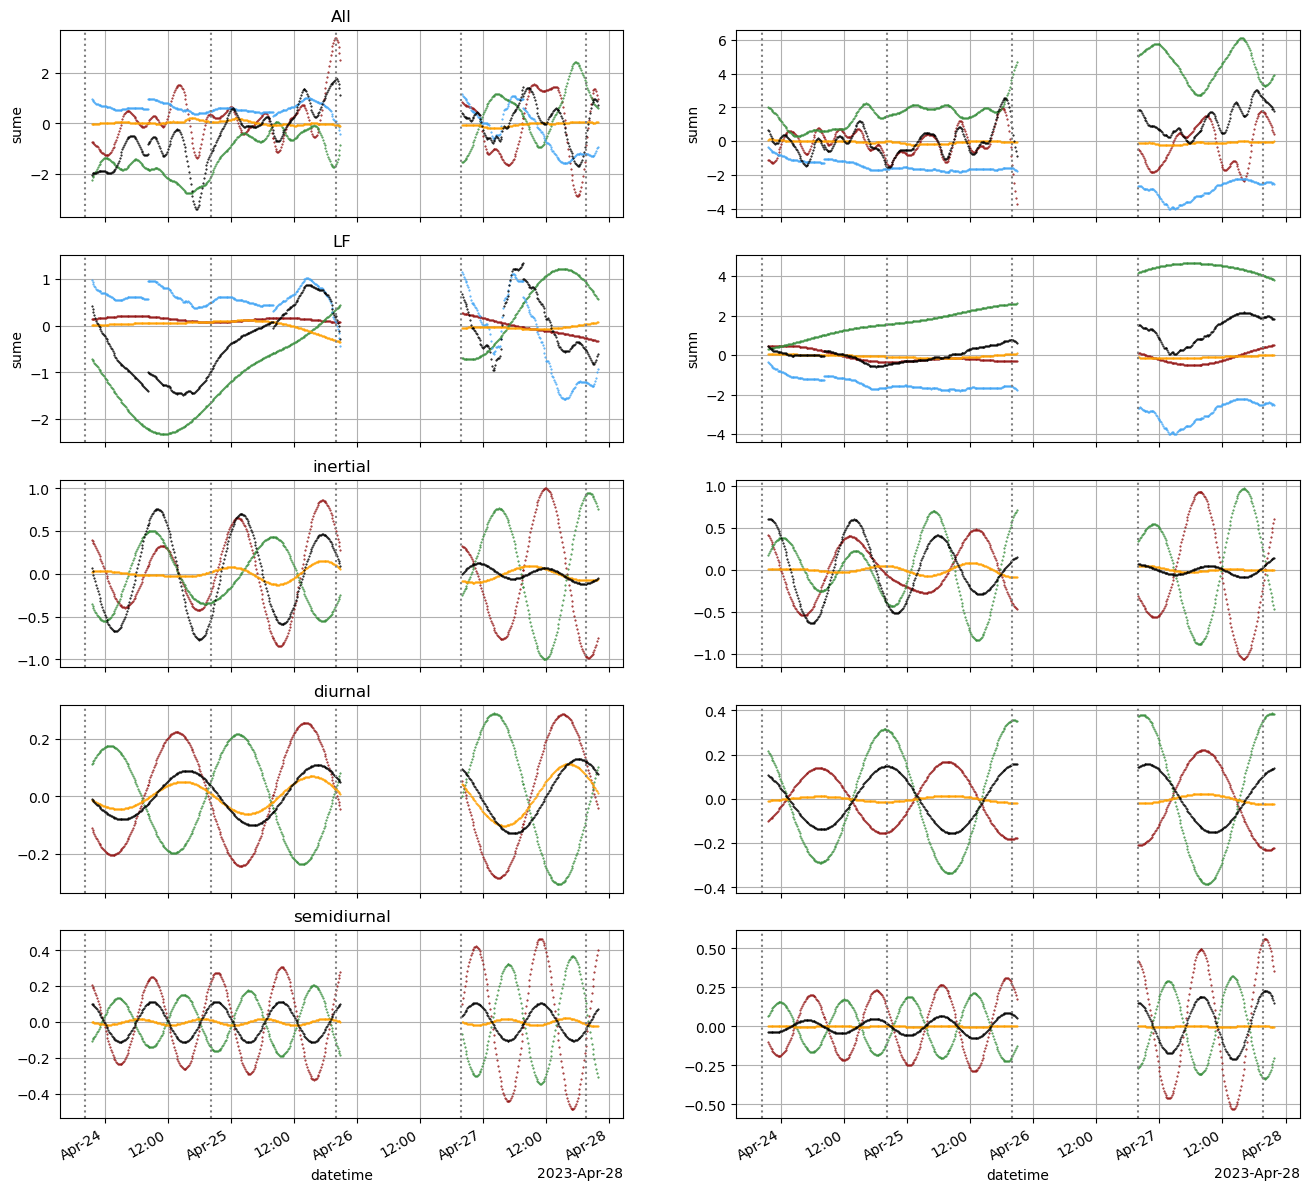

In [12]:
plot_timeseries_all(DF0, 3)